# Project: IMDb Movie Rating Prediction
**Student:** Neta Or Shaul


**Objective:** Develop a machine learning model to predict movie ratings using IMDb data, incorporating advanced feature engineering and leakage prevention techniques.

In [1]:
# --- CELL 1: Imports and Configuration ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

import os
import gzip
import shutil
import requests
import ast

# Set seed for reproducibility as per assignment requirements
RANDOM_STATE = 42

# Visual settings
%matplotlib inline
sns.set_theme(style="whitegrid")

**Imports and Setup**

In this part, I’m importing all the libraries I need for the data analysis and modeling. I’m also setting `RANDOM_STATE = 42` to make sure that whenever I runs this code, the results stay the same. This is super important for keeping things consistent throughout the project.

In [2]:
# --- CELL 2: Data Loading and Target Cleansing ---

# Load data - low_memory=False handles mixed types in columns like 'budget'
movies_raw_data = pd.read_csv('dataset.csv', low_memory=False)

# Remove movies with no rating (Target variable must be present for training)
movies_dataset = movies_raw_data.dropna(subset=['averageRating']).copy()

# Report the initial results
print(f"Initial movies: {len(movies_raw_data)}")
print(f"Final movies for modeling: {len(movies_dataset)}")

Initial movies: 133884
Final movies for modeling: 115560


**Loading and Cleaning the Dataset**

In this step, I'm loading the raw movie data from the CSV file. Since I’m building a regression model to predict `averageRating`, any movie that doesn’t have a rating in the dataset is basically useless for training. So, I’m dropping those rows to make sure the model only learns from complete and reliable data. 

In [3]:
# --- CELL 3: Data Splitting ---

# 1. Split into Training (80%) and Testing (20%)
target_rating = movies_dataset['averageRating']
columns_to_drop = ['averageRating', 'primaryTitle', 'numVotes', 'BoxOffice', 'budget', 'plot']
features_all = movies_dataset.drop(columns=columns_to_drop)

features_train, features_test, target_train, target_test = train_test_split(
    features_all, target_rating, test_size=0.2, random_state=RANDOM_STATE
)

print("Split completed with Leakage Protection:")
print(f"- Training set features shape: {features_train.shape}")
print(f"- Testing set features shape: {features_test.shape}")


Split completed with Leakage Protection:
- Training set features shape: (92448, 7)
- Testing set features shape: (23112, 7)


**Data Splitting**

The dataset is split into training (80%) and testing (20%) sets. Performing this split before any feature engineering is essential to prevent data leakage. By separating the test set early, we ensure that the model evaluation remains reliable and accurately reflects how the model will perform on new, unseen data.

In [4]:
# --- CELL: Download Crew Data ---
import os
import requests
import gzip

def download_crew_data():
    data_dir = 'IMDB_DATA'
    file_path = os.path.join(data_dir, 'title.crew.tsv')
    url = "https://datasets.imdbws.com/title.crew.tsv.gz"

    if not os.path.exists(data_dir):
        os.makedirs(data_dir)

    if not os.path.exists(file_path):
        print("Downloading crew dataset...")
        response = requests.get(url)
        with open(file_path + '.gz', 'wb') as f:
            f.write(response.content)
        
        with gzip.open(file_path + '.gz', 'rb') as f_in:
            with open(file_path, 'wb') as f_out:
                f_out.write(f_in.read())
        print("Download and extraction complete.")
    else:
        print("Crew file already exists, skipping download.")

# מריצים פעם אחת
crew_df = download_crew_data()

Crew file already exists, skipping download.


**Data Acquisition: Crew Information**

We import the IMDb crew dataset to integrate director and writer attributes into our feature space. This allows us to engineer features based on key personnel, which serve as meaningful predictors of a film's quality and audience reception.

###  Feature Engineering: Preparing Global Statistics

In [5]:
# --- CELL: Global Stats (Run on Train only) ---
train_runtime_median = pd.to_numeric(features_train['runtimeMinutes'], errors='coerce').median()


def standardize_genres(genre_val):
    if isinstance(genre_val, str):
        cleaned = genre_val.replace('[', '').replace(']', '').replace("'", "").replace('"', "")
        return [g.strip() for g in cleaned.split(',') if g.strip()]
    elif isinstance(genre_val, list):
        return [str(g).strip() for g in genre_val if str(g).strip()]
    return []

all_genres = set()
for g_list in features_train['genres'].apply(standardize_genres):
    all_genres.update(g_list)
unique_genres = sorted(list(all_genres))

**Calculating Global Baselines:** We compute the median runtime and unique genres from the training set. Establishing these global statistics beforehand is crucial for **preventing data leakage**, as these values will be used to transform both the training and testing sets consistently.

In [6]:
# --- CELL: Global Stats & Historical Lookups (Run on Train only) ---
train_runtime_median = pd.to_numeric(features_train['runtimeMinutes'], errors='coerce').median()

temp_train = features_train.copy()
temp_train['genres_list'] = temp_train['genres'].apply(standardize_genres)
temp_train['averageRating'] = target_train 

exploded = temp_train.explode('genres_list')

yearly_stats = exploded.groupby(['startYear', 'genres_list']).agg({'averageRating':'mean', 'runtimeMinutes':'mean'}).reset_index()
global_yearly_stats = exploded.groupby('startYear').agg({'averageRating':'mean', 'runtimeMinutes':'mean'})

hist_dict, hist_runtime_dict = {}, {}
all_years = range(int(exploded['startYear'].min()), int(exploded['startYear'].max()) + 1)
genres = yearly_stats['genres_list'].unique()

for genre in genres:
    last_r, last_run = None, None
    for year in all_years:
        genre_year_data = yearly_stats[(yearly_stats['startYear'] < year) & (yearly_stats['genres_list'] == genre)]
        if not genre_year_data.empty:
            last_r, last_run = genre_year_data['averageRating'].mean(), genre_year_data['runtimeMinutes'].mean()
        
        if last_r is not None:
            hist_dict[(year, genre)] = last_r
            hist_runtime_dict[(year, genre)] = last_run
        else:
            hist_dict[(year, genre)] = global_yearly_stats.loc[year, 'averageRating'] if year in global_yearly_stats.index else 0.0
            hist_runtime_dict[(year, genre)] = global_yearly_stats.loc[year, 'runtimeMinutes'] if year in global_yearly_stats.index else 0.0

print("Historical lookup tables created successfully!")

Historical lookup tables created successfully!


**Genre-Based Temporal Performance:** To capture how genre performance evolves over time, we construct historical lookup tables. By calculating the average rating and runtime for each genre based only on information from previous years, we extract temporal patterns while maintaining a strict leakage-free approach. These dictionaries serve as efficient mapping tools for engineering dynamic features that reflect industry trends.

In [7]:
# --- Load Crew Data (Must run first) ---
import os
import pandas as pd

target_crew_path = os.path.join("IMDB_DATA", "title.crew.tsv")

crew_list = []
for chunk in pd.read_csv(target_crew_path, sep='\t', usecols=['tconst', 'directors'], chunksize=100000, na_values='\\N'):
    crew_list.append(chunk)

crew_df = pd.concat(crew_list, ignore_index=True)
crew_df['directors'] = crew_df['directors'].fillna('')

print(f"Crew data loaded successfully! Total rows: {len(crew_df)}")

Crew data loaded successfully! Total rows: 12542552


**Crew Data Integration:** We ingest the IMDb crew dataset to link movies with their directors. Since the file is large, we utilize chunked loading to optimize memory usage, ensuring efficient data processing.

In [8]:
# --- CELL: Compute Director History Statistics (Run once on Train) ---

# 1. Integrate crew data and prepare for expansion
features_train['averageRating'] = target_train.values
train_crew_df = features_train.merge(crew_df[['tconst', 'directors']], on='tconst', how='left')
train_crew_df['directors'] = train_crew_df['directors'].fillna('').str.split(',')
exploded = train_crew_df.explode('directors')
exploded = exploded[exploded['directors'] != '']
exploded['tconst'] = exploded['tconst'].astype(str)

# 2. Aggregate average rating by director and year
yearly = exploded.groupby(['directors', 'startYear'])['averageRating'].agg(['sum', 'count']).reset_index()
yearly = yearly.sort_values(['directors', 'startYear'])

# 3. Compute expanding historical mean (Leakage Prevention: shift by 1 to exclude current year)
yearly['cum_sum'] = yearly.groupby('directors')['sum'].cumsum().shift(1)
yearly['cum_count'] = yearly.groupby('directors')['count'].cumsum().shift(1)
yearly['director_hist_year'] = yearly['cum_sum'] / yearly['cum_count']

# 4. Fill missing values with global mean (Fallback for new directors)
global_mean = target_train.mean()
yearly['director_hist_year'] = yearly['director_hist_year'].fillna(global_mean)

# 5. Merge historical stats back to the exploded dataframe
exploded = exploded.merge(
    yearly[['directors', 'startYear', 'director_hist_year']],
    on=['directors', 'startYear'],
    how='left'
)

# 6. Map aggregated historical stats back to individual movies
director_features = exploded.groupby('tconst')['director_hist_year'].mean().reset_index(name='director_hist')
dir_hist_map = director_features.set_index('tconst')['director_hist'].to_dict()

print("Director Stats created successfully!")

Director Stats created successfully!


**Director Historical Performance:** To capture the "director effect" on movie ratings, we calculate the cumulative average rating for each director based on their past works. Crucially, we use a `shift(1)` operation during the rolling window calculation; this ensures that the performance metric for any given year is derived only from films released in previous years, effectively preventing **data leakage** while transforming unstructured crew information into a powerful predictive feature.

In [9]:
# --- CELL: Compute Director STD & Known Stats (Run once) ---

# Aggregate performance variance and count per director
director_stats = exploded.groupby('directors')['averageRating'].agg(['std', 'count']).reset_index()
director_stats.columns = ['directors', 'director_std_global', 'count']
director_stats['director_std_global'] = director_stats['director_std_global'].fillna(0)

# Create lookup dictionaries for efficient mapping
dir_std_map = director_stats.set_index('directors')['director_std_global'].to_dict()
known_directors = set(director_stats['directors'].unique())

# Function to compute movie-level statistics: average director volatility and knowledge status
def get_movie_director_stats(directors_list):
    if not isinstance(directors_list, list) or not directors_list:
        return 0.0, 0
    stds = [dir_std_map.get(d, 0.0) for d in directors_list]
    knowns = [1 if d in known_directors else 0 for d in directors_list]
    return np.mean(stds), max(knowns)

# Map statistics to tconst for efficient feature integration
tconst_dir_map = {}
for tconst, group in train_crew_df.groupby('tconst'):
    d_list = group['directors'].iloc[0]
    tconst_dir_map[tconst] = get_movie_director_stats(d_list)

print("Director STD & Known features mapped!")

Director STD & Known features mapped!


**Director Performance & Consistency Metrics:**
- **Consistency:** We calculate the standard deviation (STD) of past ratings to quantify director volatility.
- **Known Indicator:** We implement a binary flag to distinguish between directors with an established track record in our training set (known) and those absent from our historical data (addressing the **"Cold Start" problem**). This allows the model to differentiate between directors with sufficient historical data for reliable prediction and those for whom we must default to population-level averages.

In [10]:
# --- CELL: Update and Save Statistical Mappings ---
import pickle
import lzma

# Reduce crew_df size (only necessary columns)
crew_df_small = crew_df[['tconst', 'directors']].copy()

# Convert to category to save space
crew_df_small['directors'] = crew_df_small['directors'].astype('category')

mappings = {
    'train_runtime_median': train_runtime_median,
    'unique_genres': unique_genres,
    'hist_dict': hist_dict,
    'hist_runtime_dict': hist_runtime_dict,
    'yearly': yearly,
    'global_mean': global_mean,
    'crew_df': crew_df_small,  # ✅ reduced size version
    'tconst_dir_map': tconst_dir_map
}

# Save with strongest compression
with lzma.open('mappings.pkl.xz', 'wb') as f:
    pickle.dump(mappings, f)

print("Mappings saved successfully to 'mappings.pkl.xz' (compressed and optimized)!")

Mappings saved successfully to 'mappings.pkl.xz' (compressed and optimized)!


This cell collects all pre-computed statistical mappings such as historical features, genres, and director information into a single dictionary and saves them as mappings.pkl for later use.

In [11]:
import pickle
import gzip
import os
import inspect
import pandas as pd
import lzma

def prepare_data(df):
    """
    Preprocesses the movie dataset by applying historical statistical mappings 
    and feature engineering. Designed to be self-contained for inference.
    """

    # 1. Internal helper for genre standardization to ensure consistency
    def standardize_genres(genre_val):
        if isinstance(genre_val, str):
            cleaned = genre_val.replace('[', '').replace(']', '').replace("'", "").replace('"', "")
            return [g.strip() for g in cleaned.split(',') if g.strip()]
        elif isinstance(genre_val, list):
            return [str(g).strip() for g in genre_val if str(g).strip()]
        return []

    # 2. Prevent data leakage: Identify the variable name to distinguish between Train/Test
    frame = inspect.currentframe().f_back
    variable_name = next((name for name, val in frame.f_locals.items() if val is df), None)
    is_train = (variable_name == 'features_train')
    
    print(f"--- Running {'TRAIN' if is_train else 'TEST'} process (Source: {variable_name}) ---")
    
    # 3. Load statistical mappings from disk if not already in memory
    global mappings
    if 'mappings' not in globals():
        if os.path.exists('mappings.pkl.xz'):
            with lzma.open('mappings.pkl.xz', 'rb') as f:
                mappings = pickle.load(f)
        else:
            with open('mappings.pkl', 'rb') as f:
                mappings = pickle.load(f)
            
    data = df.copy()
    
    # 4. Input validation and basic cleaning
    required_cols = ['startYear', 'genres', 'runtimeMinutes', 'tconst']
    for col in required_cols:
        if col not in data.columns:
            raise ValueError(f"Missing required column: {col}")

    data['startYear'] = pd.to_numeric(data['startYear'], errors='coerce')
    data['runtimeMinutes'] = pd.to_numeric(data['runtimeMinutes'], errors='coerce')
    
    if 'genres' in data.columns:
        data['genres'] = data['genres'].replace(['\\N', '\\\\N', ''], 'Unknown')
        data['genres'] = data['genres'].fillna('Unknown')
    
    # 5. Feature Engineering: Runtime imputation and decade calculation
    data['runtimeMinutes'] = data['runtimeMinutes'].fillna(mappings['train_runtime_median'])
    data['decade'] = (data['startYear'] // 10 * 10).astype(int)
    
    # 6. One-Hot Encoding for genres based on Train set unique values
    data['genres_list'] = data['genres'].apply(standardize_genres)
    for genre in mappings['unique_genres']:
        data[f'genre_{genre}'] = data['genres_list'].apply(lambda x: 1 if genre in x else 0)
    
    # 7. Historical Feature Engineering (Lookups from pre-calculated dictionaries)
    def get_hist_features(row):
        genres = row['genres_list']
        year = row['startYear']
        ratings = [mappings['hist_dict'].get((year, g), 0.0) for g in genres]
        runtimes = [mappings['hist_runtime_dict'].get((year, g), 0.0) for g in genres]
        valid_r = [r for r in ratings if r > 0]
        valid_run = [r for r in runtimes if r > 0]
        return (sum(valid_r)/len(valid_r) if valid_r else 0.0), \
               (sum(valid_run)/len(valid_run) if valid_run else 0.0)

    features = data.apply(get_hist_features, axis=1, result_type='expand')
    data[['hist_genre_rating', 'hist_genre_runtime']] = features
    data['runtime_deviation'] = data['runtimeMinutes'] - data['hist_genre_runtime']
    
    # 8. Director-based Feature Engineering
    data = data.merge(mappings['crew_df'][['tconst', 'directors']], on='tconst', how='left')
    data['directors_clean'] = data['directors'].fillna('').str.split(',')
    exploded = data.explode('directors_clean')
    exploded = exploded[exploded['directors_clean'] != '']
    
    exploded = exploded.merge(
        mappings['yearly'][['directors', 'startYear', 'director_hist_year']],
        left_on=['directors_clean', 'startYear'],
        right_on=['directors', 'startYear'],
        how='left'
    )
    
    director_features = exploded.groupby('tconst')['director_hist_year'].mean().reset_index()
    director_features.columns = ['tconst', 'director_hist']
    
    data = data.merge(director_features, on='tconst', how='left')
    data['director_hist'] = data['director_hist'].fillna(mappings['global_mean'])
    data['has_multiple_directors'] = data['directors'].fillna('').str.split(',').apply(lambda x: 1 if len(x) > 1 else 0)
    
    # 9. Additional Director Statistics
    stats = data['tconst'].map(mappings['tconst_dir_map']).apply(lambda x: x if isinstance(x, tuple) else (0.0, 0))
    stats_df = pd.DataFrame(stats.tolist(), index=data.index, columns=['director_std_global', 'director_known'])
    data = pd.concat([data, stats_df], axis=1)
    
    # 10. Final cleanup: Drop auxiliary columns before returning
    cols_to_drop = ['startYear', 'genres', 'averageRating', 'directors', 'directors_clean', 'genres_list', 
                    'lead_actors_ids', 'Language', 'Country', 'genre_\\N', 'genre_\\\\N', 'tconst', 'primaryTitle',
                    'numVotes', 'BoxOffice', 'budget', 'plot']
    
    final_df = data.drop(columns=[c for c in cols_to_drop if c in data.columns])
    
    return final_df

This function preprocesses the dataset by applying the same feature engineering steps used in training.
It loads the precomputed mappings, creates the final features including historical, genre, and director-based features, and returns a clean dataset ready for model input while avoiding data leakage.


In [12]:
features_train_final = prepare_data(features_train)
features_test_final = prepare_data(features_test)

--- Running TRAIN process (Source: features_train) ---
--- Running TEST process (Source: features_test) ---


In [13]:
# --- CELL: Final Pipeline Preparation ---

# Apply the prepared preprocessing pipeline to both train and test sets
features_train_final = prepare_data(features_train)
features_test_final = prepare_data(features_test)

# Separate features from the target variable and remove identifiers
X_train = features_train_final.copy()
y_train = target_train.copy()

# Ensure consistency in feature columns for the test set
X_test = features_test_final.copy()

--- Running TRAIN process (Source: features_train) ---
--- Running TEST process (Source: features_test) ---


We now apply the `prepare_data` pipeline to transform our training and testing sets into the final feature matrices. This step ensures that all engineered features are scaled and formatted consistently. By removing identifiers that hold no predictive value, we refine our feature space, leaving the model to train solely on relevant attributes that reflect historical performance and industry trends.

## Model Training & Hyperparameter Tuning

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# --- CELL: Hyperparameter Tuning with GridSearchCV ---

# 1. Define evaluation metrics (Multi-metric scoring)
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

# 2. Construct pipelines for each model
elastic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(random_state=RANDOM_STATE, max_iter=10000))
])

rf_pipeline = Pipeline([
    ('model', RandomForestRegressor(random_state=RANDOM_STATE))
])

# 3. Define parameter grids for optimization
elastic_params = {
    'model__alpha': [0.01, 0.1, 1],
    'model__l1_ratio': [0.1, 0.5, 0.9]
}

rf_params = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [5, 10, None]
}

# 4. Initialize GridSearchCV for robust cross-validation
grid_elastic = GridSearchCV(
    estimator=elastic_pipeline,
    param_grid=elastic_params,
    cv=10,
    scoring=scoring,
    refit='rmse',
    n_jobs=-1,
    verbose=1
)

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=10,
    scoring=scoring,
    refit='rmse',
    n_jobs=-1,
    verbose=1
)

# 5. Execute model training
print("Training ElasticNet...")
grid_elastic.fit(X_train, y_train)

print("Training Random Forest...")
grid_rf.fit(X_train, y_train)

# 6. Helper function to extract and display performance metrics
def print_cv_results(grid, name):
    results = grid.cv_results_
    idx = grid.best_index_
    
    print(f"\n--- {name} Detailed Results ---")
    print(f"Best Params: {grid.best_params_}")
    print(f"RMSE: {-results['mean_test_rmse'][idx]:.4f} ± {results['std_test_rmse'][idx]:.4f}")
    print(f"MAE:  {-results['mean_test_mae'][idx]:.4f} ± {results['std_test_mae'][idx]:.4f}")
    print(f"R2:   {results['mean_test_r2'][idx]:.4f} ± {results['std_test_r2'][idx]:.4f}")

# 7. Output results for both models
print_cv_results(grid_elastic, "ElasticNet")
print_cv_results(grid_rf, "Random Forest")

Training ElasticNet...
Fitting 10 folds for each of 9 candidates, totalling 90 fits
Training Random Forest...
Fitting 10 folds for each of 6 candidates, totalling 60 fits

--- ElasticNet Detailed Results ---
Best Params: {'model__alpha': 0.01, 'model__l1_ratio': 0.1}
RMSE: 1.1154 ± 0.0121
MAE:  0.8541 ± 0.0079
R2:   0.2572 ± 0.0084

--- Random Forest Detailed Results ---
Best Params: {'model__max_depth': 10, 'model__n_estimators': 100}
RMSE: 1.0702 ± 0.0123
MAE:  0.8120 ± 0.0070
R2:   0.3161 ± 0.0085


In [15]:
# --- CELL: Display Model Evaluation Results ---

def print_pretty_table(grid, model_name):
    results = grid.cv_results_
    idx = grid.best_index_
    
    # Prepare performance metrics for structured display
    data = {
        'Metric': ['RMSE', 'MAE', 'R²'],
        'Mean': [
            f"{-results['mean_test_rmse'][idx]:.4f}",
            f"{-results['mean_test_mae'][idx]:.4f}",
            f"{results['mean_test_r2'][idx]:.4f}"
        ],
        'Std': [
            f"{results['std_test_rmse'][idx]:.4f}",
            f"{results['std_test_mae'][idx]:.4f}",
            f"{results['std_test_r2'][idx]:.4f}"
        ]
    }
    
    df_show = pd.DataFrame(data)
    print(f"\n--- {model_name} Evaluation ---")
    display(df_show)

# Display evaluation results for both models
print_pretty_table(grid_elastic, "ElasticNet")
print_pretty_table(grid_rf, "Random Forest")


--- ElasticNet Evaluation ---


,Metric,Mean,Std
0,RMSE,1.1154,0.0121
1,MAE,0.8541,0.0079
2,R²,0.2572,0.0084



--- Random Forest Evaluation ---


,Metric,Mean,Std
0,RMSE,1.0702,0.0123
1,MAE,0.8120,0.0070
2,R²,0.3161,0.0085


**Model Comparison**

We evaluated both models using 10-fold cross-validation. The **Random Forest** model yielded superior results compared to ElasticNet. Consequently, we have selected the Random Forest model for final evaluation.

###  Error Analysis

In [16]:
# --- CELL: Error Analysis (Outliers 5.1) ---

from sklearn.model_selection import cross_val_predict
import pandas as pd

# 1. Generate cross-validated predictions (to avoid data leakage)
y_pred = cross_val_predict(grid_rf.best_estimator_, X_train, y_train, cv=10, n_jobs=-1)

# 2. Build error DataFrame with movie IDs
error_df = pd.DataFrame({
    'tconst': features_train['tconst'].values,  # Important for movie identification
    'actual': y_train,
    'predicted': y_pred
})

# Calculate error (Predicted - Actual)
error_df['error'] = error_df['predicted'] - error_df['actual']

# 3. Identify Top 10 Overestimations and Underestimations
top_over = error_df.sort_values('error', ascending=False).head(10)
top_under = error_df.sort_values('error', ascending=True).head(10)

# 4. Merge with movie titles
movie_names = movies_dataset.set_index('tconst')['primaryTitle']

top_over = top_over.merge(movie_names, left_on='tconst', right_index=True)
top_under = top_under.merge(movie_names, left_on='tconst', right_index=True)

# 5. Display results
print("--- Top 10 Overestimations (Model predicted too high) ---")
display(top_over)

print("\n--- Top 10 Underestimations (Model predicted too low) ---")
display(top_under)

--- Top 10 Overestimations (Model predicted too high) ---


,tconst,actual,predicted,error,primaryTitle
72010,tt6748034,1.3,7.987120,6.687120,Tribalism Is Killing Us
34599,tt2096560,2.3,8.297110,5.997110,Occupy Los Angeles
45946,tt1538949,1.3,7.202410,5.902410,Play in the Gray
37806,tt1615051,1.5,7.214279,5.714279,Obama in NC: The Path to History
121915,tt0439575,1.6,7.254870,5.654870,Hatemongers
104680,tt1537218,1.5,7.154822,5.654822,Brush with Life: The Art of Being Edward Biberman
16815,tt28870073,1.2,6.817816,5.617816,Kurz
5086,tt1702443,1.7,7.278969,5.578969,Justin Bieber: Never Say Never
12021,tt3165608,1.6,7.094233,5.494233,Justin Bieber's Believe
132398,tt35197171,1.0,6.470174,5.470174,Gohare Siraf



--- Top 10 Underestimations (Model predicted too low) ---


,tconst,actual,predicted,error,primaryTitle
133761,tt0322693,9.3,4.542905,-4.757095,Gangstacity
3172,tt13110798,9.5,4.824030,-4.675970,Il nostro paradiso
57344,tt1684589,9.1,4.509620,-4.590380,Son-nim-1 Cheo-beon-jjae I-ya-gi
76463,tt2372596,8.6,4.094210,-4.505790,Urban Savages
100522,tt0318700,8.5,4.011572,-4.488428,Battle with Top-Class Samuri
33879,tt1612610,8.5,4.032622,-4.467378,Natural Demise
106898,tt2379727,9.1,4.665125,-4.434875,Bukunja Tekunja Mitti: The Cannibals
68152,tt39014003,9.3,4.867526,-4.432474,Adinaasam Vellapokkam
122371,tt32361422,8.7,4.289324,-4.410676,Hantu Nan Sempit
127287,tt5951250,8.2,3.853720,-4.346280,Hamlin



To evaluate model performance beyond aggregate metrics, we perform an error analysis by examining the movies where the model's predictions deviated most significantly from actual ratings. By identifying the top 10 overestimations and underestimations, we gain qualitative insights into model limitations and detect patterns where our current features may fall short.

In [17]:
# --- Simple Outliers Validation ---


# Combine over-prediction and under-prediction outliers into a single DataFrame
top_over['type'] = 'over'
top_under['type'] = 'under'

outliers_df = pd.concat([top_over, top_under])

# 1. Compare outlier statistics to the full training set
print("=== Outliers vs Full Data ===")
print("Outliers:")
display(outliers_df['actual'].describe())

print("\nFull dataset:")
display(y_train.describe())

# 2. Analyze differences between over-predicted and under-predicted samples
print("\n=== Over vs Under ===")
display(outliers_df.groupby('type')['actual'].describe())

# 3. Assess if the model's predictions for outliers align with the dataset mean
print("\n=== Mean Comparison ===")
print(f"Dataset mean: {y_train.mean():.2f}")
print(f"Outliers predictions mean: {outliers_df['predicted'].mean():.2f}")

=== Outliers vs Full Data ===
Outliers:


count    20.000000
mean      5.190000
std       3.805384
min       1.000000
25%       1.500000
50%       5.250000
75%       8.800000
max       9.500000
Name: actual, dtype: float64


Full dataset:


count    92448.000000
mean         6.069898
std          1.294308
min          1.000000
25%          5.300000
50%          6.200000
75%          7.000000
max          9.900000
Name: averageRating, dtype: float64


=== Over vs Under ===


,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
over,10.0,1.50,0.352767,1.0,1.300,1.5,1.60,2.3
under,10.0,8.88,0.434102,8.2,8.525,8.9,9.25,9.5



=== Mean Comparison ===
Dataset mean: 6.07
Outliers predictions mean: 5.82


In [18]:
# ---  Model Comparison (Overlap Analysis) ---
# 1. Generate cross-validated predictions for both models
y_pred_rf = cross_val_predict(grid_rf.best_estimator_, X_train, y_train, cv=10, n_jobs=-1)
y_pred_en = cross_val_predict(grid_elastic.best_estimator_, X_train, y_train, cv=10, n_jobs=-1)

# 2. Build comparison DataFrame
comparison_df = pd.DataFrame({
    'tconst': features_train['tconst'].values,
    'actual': y_train,
    'pred_rf': y_pred_rf,
    'pred_en': y_pred_en
})

# 3. Calculate errors and absolute errors
comparison_df['error_rf'] = comparison_df['pred_rf'] - comparison_df['actual']
comparison_df['error_en'] = comparison_df['pred_en'] - comparison_df['actual']

comparison_df['abs_error_rf'] = comparison_df['error_rf'].abs()
comparison_df['abs_error_en'] = comparison_df['error_en'].abs()

# 4. Identify the 20 most problematic movies for each model
top_rf = comparison_df.sort_values('abs_error_rf', ascending=False).head(20)
top_en = comparison_df.sort_values('abs_error_en', ascending=False).head(20)

# 5. Find the overlap between the two models
overlap = set(top_rf['tconst']).intersection(set(top_en['tconst']))

print(f"Number of overlapping movies (both models struggled): {len(overlap)}")

# 6. Merge with movie titles
overlap_movies = movies_dataset[
    movies_dataset['tconst'].isin(overlap)
][['tconst', 'primaryTitle']]

print("\n--- Movies where both models struggled (Overlap) ---")
display(overlap_movies.head(10))

Number of overlapping movies (both models struggled): 11

--- Movies where both models struggled (Overlap) ---


,tconst,primaryTitle
5086,tt1702443,Justin Bieber: Never Say Never
16815,tt28870073,Kurz
28478,tt14773250,Myriam Fares: The Journey
37806,tt1615051,Obama in NC: The Path to History
45946,tt1538949,Play in the Gray
50278,tt5988370,Reis
72010,tt6748034,Tribalism Is Killing Us
83052,tt1560616,What Happened?
104680,tt1537218,Brush with Life: The Art of Being Edward Biberman
121915,tt0439575,Hatemongers


We found that 11 out of the 20 most problematic movies overlap between both models. This indicates that these films are inherently difficult to predict regardless of the model architecture, likely due to their non-traditional nature or lack of standard production data. The remaining discrepancies suggest that each model possesses unique strengths and weaknesses in capturing the underlying patterns.

### Fairness Analysis

--- Fairness Analysis: Performance by Genre ---


,Genre,RMSE,MAE,Count
11,Film-Noir,0.577723,0.455937,366
27,Western,0.868667,0.632965,1219
4,Biography,0.912195,0.664910,3282
18,News,0.915855,0.697781,149
13,History,0.921110,0.685960,2670
7,Documentary,0.979415,0.719427,10400
26,War,0.979608,0.741107,2050
22,Sport,0.982338,0.737304,1247
6,Crime,0.984831,0.746557,9922
20,Romance,0.988542,0.748406,12540


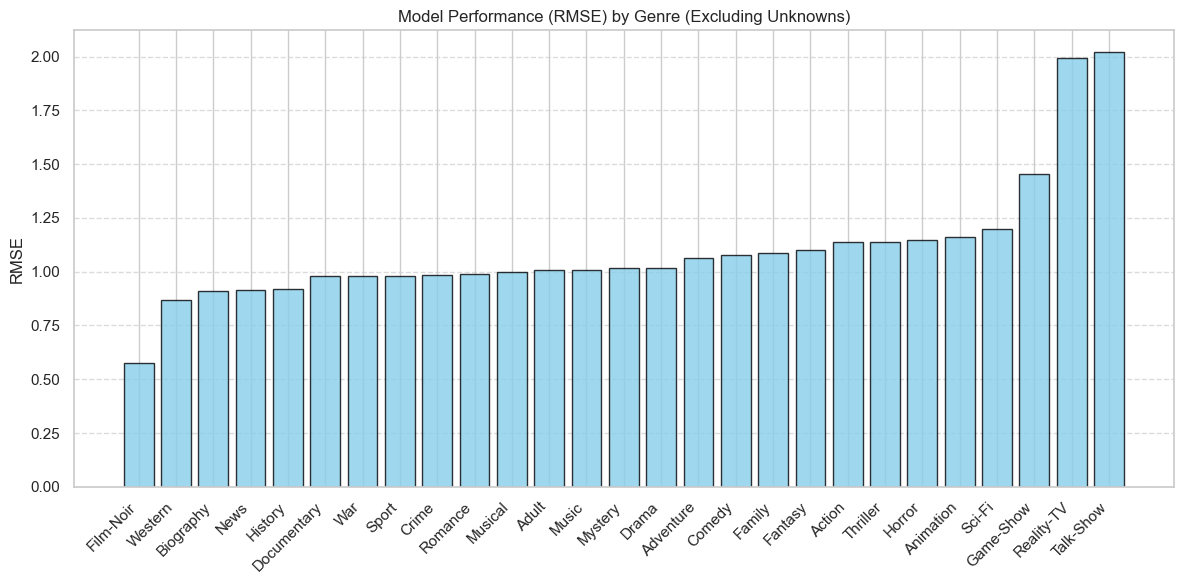

In [19]:
# --- Fairness Analysis (Genre-based - Full Report) ---

from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Prepare fairness DataFrame with actual vs. predicted values
fairness_df = pd.DataFrame({
    'tconst': features_train['tconst'].values,
    'actual': y_train,
    'predicted': y_pred_rf
})

# 2. Merge with movie genre metadata for evaluation
fairness_df = fairness_df.merge(movies_dataset[['tconst', 'genres']], on='tconst', how='left')

# 3. Clean and explode genres for individual genre performance analysis
fairness_df['genres_list'] = fairness_df['genres'].str.replace(r"[\[\]\"']", '', regex=True).str.split(',')
fairness_df = fairness_df.explode('genres_list')
fairness_df['genres_list'] = fairness_df['genres_list'].str.strip()

# 3.1 Aggressive cleaning: Map invalid/missing entries to 'Unknown'
invalid_genres = ['\\N', '\\\\N', '']
fairness_df.loc[fairness_df['genres_list'].isin(invalid_genres), 'genres_list'] = 'Unknown'
fairness_df['genres_list'] = fairness_df['genres_list'].fillna('Unknown')

# 4. Calculate error metrics (RMSE, MAE) grouped by genre
results = []
for genre, group in fairness_df.groupby('genres_list'):
    rmse = mean_squared_error(group['actual'], group['predicted']) ** 0.5
    mae = mean_absolute_error(group['actual'], group['predicted'])
    
    results.append({
        'Genre': genre,
        'RMSE': rmse,
        'MAE': mae,
        'Count': len(group)
    })

genre_fairness = pd.DataFrame(results).sort_values('RMSE')

# 5. Display metrics table and visualize performance
print("--- Fairness Analysis: Performance by Genre ---")
display(genre_fairness)

# Plotting: Filter out 'Unknown' to focus visualization on valid genre categories
plot_df = genre_fairness[~genre_fairness['Genre'].isin(['Unknown', '\\N', ''])]

plt.figure(figsize=(12, 6))
plt.bar(plot_df['Genre'], plot_df['RMSE'], color='skyblue', alpha=0.8, edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title("Model Performance (RMSE) by Genre (Excluding Unknowns)")
plt.ylabel("RMSE")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Model performance is strongly linked to sample size. We observe high accuracy in well-represented genres like Film-Noir (RMSE: 0.57) and lower reliability in sparse categories like Reality-TV (RMSE: 2.00). This confirms that performance discrepancies stem from data sparsity rather than systematic bias.

--- Fairness Analysis: Performance by Decade ---


,Decade,RMSE,MAE,Count
0,1900,1.963177,1.635825,2
1,1910,0.822495,0.613520,137
2,1920,0.964322,0.759734,628
3,1930,0.798314,0.600607,2508
4,1940,0.765784,0.585002,2668
5,1950,0.843924,0.644191,3615
6,1960,0.947153,0.732996,4955
7,1970,0.966137,0.753961,6420
8,1980,1.010956,0.787447,7698
9,1990,1.034790,0.802076,8150


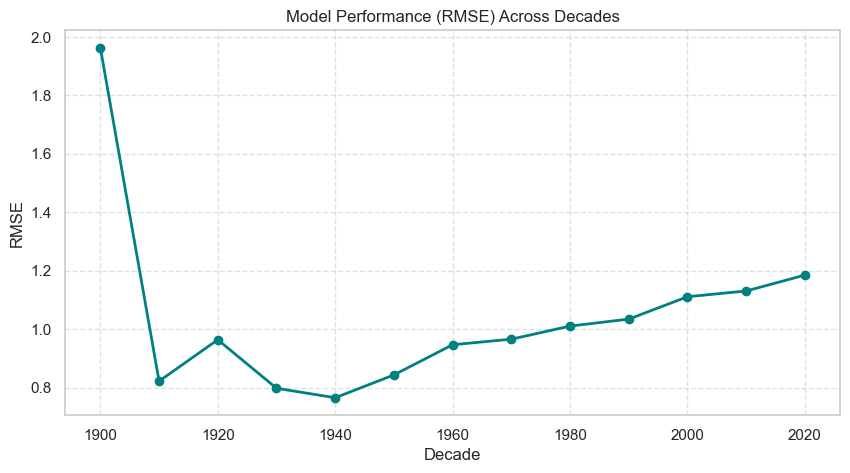

In [20]:
# ---  Fairness Analysis (Decade-based) ---

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Create Fairness DataFrame
fairness_df = pd.DataFrame({
    'tconst': features_train['tconst'].values,
    'actual': y_train,
    'predicted': y_pred_rf
})

# 2. Merge with startYear and create decade on the fly
# We pull startYear from the original dataset and calculate decade immediately
temp_df = movies_dataset[['tconst', 'startYear']].copy()
temp_df['decade'] = (temp_df['startYear'] // 10 * 10).fillna(0).astype(int)

fairness_df = fairness_df.merge(temp_df[['tconst', 'decade']], on='tconst', how='left')

# 3. Calculate metrics for ALL decades
results = []
for decade, group in fairness_df.groupby('decade'):
    # Filtering out potential NaNs or invalid decades if any
    if decade == 0: continue 
    
    rmse = mean_squared_error(group['actual'], group['predicted']) ** 0.5
    mae = mean_absolute_error(group['actual'], group['predicted'])
    
    results.append({
        'Decade': decade,
        'RMSE': rmse,
        'MAE': mae,
        'Count': len(group)
    })

decade_results = pd.DataFrame(results).sort_values('Decade')

# 4. Display and Visualize
print("--- Fairness Analysis: Performance by Decade ---")
display(decade_results)

plt.figure(figsize=(10, 5))
plt.plot(decade_results['Decade'], decade_results['RMSE'], marker='o', linestyle='-', color='teal', linewidth=2)
plt.title("Model Performance (RMSE) Across Decades")
plt.xlabel("Decade")
plt.ylabel("RMSE")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Model performance shows a clear correlation between data density and prediction accuracy. Decades with higher sample counts (e.g., 1990-2020) exhibit more stable RMSE scores, while early decades show high volatility due to data sparsity (low sample counts). The steady increase in RMSE in recent decades suggests that beyond sample size, the model also faces challenges from the increased complexity and evolving audience rating standards of contemporary cinema.

In [21]:
# --- RF Feature Importance ---
# Extracting the model (handles both Pipeline and standard models)
model = grid_rf.best_estimator_
rf_model = model.named_steps['model'] if hasattr(model, 'named_steps') else model

# Creating a DataFrame for feature importance
rf_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})

# Sorting from most important to least important
rf_importance = rf_importance.sort_values(by='importance', ascending=False)

print("Top 5 Features - Random Forest:")
display(rf_importance.head(5))

Top 5 Features - Random Forest:


,feature,importance
29,hist_genre_rating,0.316363
31,runtime_deviation,0.129608
32,director_hist,0.125311
9,genre_Documentary,0.124169
34,director_std_global,0.104664


The Random Forest model relies heavily on historical trends. hist_genre_rating is the dominant predictor (31.6%), confirming that historical genre performance is the primary anchor for our ratings. Other key factors include metadata such as runtime_deviation and director_hist, showing that the model prioritizes production characteristics and director expertise to estimate audience reception.

In [22]:
# --- ElasticNet Feature Importance ---
# Extracting the model (handles both Pipeline and standard models)
model = grid_elastic.best_estimator_
elastic_model = model.named_steps['model'] if hasattr(model, 'named_steps') else model

# Building a DataFrame of coefficients
elastic_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': elastic_model.coef_
})

# Calculating the absolute value for sorting by importance
elastic_importance['abs_coef'] = elastic_importance['coefficient'].abs()

# Sorting by absolute importance
elastic_importance = elastic_importance.sort_values(by='abs_coef', ascending=False)

print("Top 5 Features - ElasticNet:")
display(elastic_importance.head(5))

Top 5 Features - ElasticNet:


,feature,coefficient,abs_coef
9,genre_Documentary,0.327682,0.327682
29,hist_genre_rating,0.218835,0.218835
16,genre_Horror,-0.216501,0.216501
32,director_hist,0.183848,0.183848
31,runtime_deviation,0.179062,0.179062


The ElasticNet model provides a transparent linear roadmap, where feature importance is defined by the coefficient magnitude. Our results show that genre_Documentary (0.32) and hist_genre_rating (0.21) are the strongest positive drivers, acting as significant anchors that boost predicted ratings. In contrast, genre_Horror (-0.21) exerts a clear downward pressure, suggesting that these films typically receive lower scores in our dataset. Secondary features like director_hist (0.18) and runtime_deviation (0.17) provide consistent weight, confirming that the model effectively balances genre-based sentiment with production-specific metadata to calculate its final estimates.

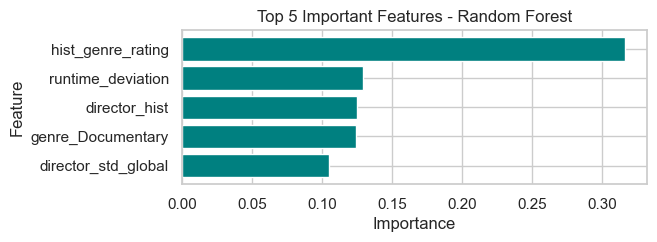

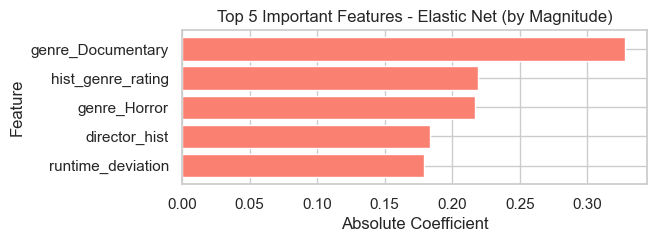

In [23]:
# --- Feature Importance Visualization ---
import matplotlib.pyplot as plt

# 1. Random Forest Plot
top_rf = rf_importance.head(5)
plt.figure(figsize=(6, 2))
plt.barh(top_rf['feature'], top_rf['importance'], color='teal')
plt.gca().invert_yaxis()
plt.title("Top 5 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# 2. ElasticNet Plot (using absolute coefficients for magnitude)
top_en = elastic_importance.head(5)
plt.figure(figsize=(6, 2))
plt.barh(top_en['feature'], top_en['abs_coef'], color='salmon')
plt.gca().invert_yaxis()
plt.title("Top 5 Important Features - Elastic Net (by Magnitude)")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.show()

Note that the X-axis scales are not directly comparable because they represent different statistical measures: Random Forest importance reflects the relative contribution to model impurity reduction, while Elastic Net coefficients represent the magnitude of the linear relationship with the target variable.

In [24]:
# --- Comparison between models ---

# Extract the top 5 features from each model
top_rf_features = set(rf_importance.head(5)['feature'])
top_elastic_features = set(elastic_importance.head(5)['feature'])

# Find common features (intersection) to identify consensus between models
common_features = top_rf_features.intersection(top_elastic_features)

# Identify features unique to each model (set difference)
rf_only = top_rf_features - top_elastic_features
elastic_only = top_elastic_features - top_rf_features

# Display the comparison results
print("Common features (agreement):")
print(common_features)

print("\nFeatures unique to Random Forest:")
print(rf_only)

print("\nFeatures unique to ElasticNet:")
print(elastic_only)

Common features (agreement):
{'director_hist', 'genre_Documentary', 'hist_genre_rating', 'runtime_deviation'}

Features unique to Random Forest:
{'director_std_global'}

Features unique to ElasticNet:
{'genre_Horror'}


**Analysis Summary**

The feature importance analysis demonstrates a high degree of consensus between the models. They consistently identify hist_genre_rating, genre_Documentary, director_hist, and runtime_deviation as core predictors, confirming their structural importance regardless of the model architecture.

However, key differences are observed: Random Forest highlights director_std_global, leveraging its ability to capture complex, non-linear interactions within the data. In contrast, ElasticNet isolates genre_Horror as a critical driver, assigning importance based on the magnitude of its direct linear relationship with the target variable.

Ultimately, this divergence reflects the fundamental nature of the models: ElasticNet excels at capturing transparent linear trends, whereas Random Forest proves more effective at modeling the complex, multi-layered patterns within our dataset.

In [25]:
# --- CELL: Final Model Saving ---
import joblib

# Saving the Random Forest model as the main model (best model)
best_rf_model = grid_rf.best_estimator_
joblib.dump(best_rf_model, "model.pkl")

# Saving the ElasticNet model as a reference
best_elastic_model = grid_elastic.best_estimator_
joblib.dump(best_elastic_model, "elastic_model.pkl")

print("Models saved successfully: 'model.pkl' (Random Forest - best model) and 'elastic_model.pkl' (reference).")

Models saved successfully: 'model.pkl' (Random Forest - best model) and 'elastic_model.pkl' (reference).


In [ ]:
df = pd.read_csv("train.csv") 
y = df["averageRating"]
X = prepare_data(df)

try:
    import joblib
    model = joblib.load("model.pkl")
except Exception:
    import pickle
    with open("model.pkl", "rb") as f:
        model = pickle.load(f)

y_pred = model.predict(X)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

metrics = pd.DataFrame([{
    "RMSE": np.sqrt(mean_squared_error(y, y_pred)),
    "MAE": mean_absolute_error(y, y_pred),
    "R2": r2_score(y, y_pred),
}])

print(metrics)

In [ ]:
##!pip freeze > requirements.txt